# Prediksi Emisi CO₂ Kendaraan Berdasarkan Ukuran Mesin

1) IMPORT LIBRARIES AND DATASETS

In [5]:
# Import Pkgs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
from google.colab import files
files.upload()

Saving fuel.csv to fuel (1).csv


{'fuel (1).csv': b'ENGINESIZE,CO2EMISSIONS\n2,196\n2.4,221\n1.5,136\n3.5,255\n3.5,244\n3.5,230\n3.5,232\n3.7,255\n3.7,267\n2.4,212\n2.4,225\n3.5,239\n5.9,359\n5.9,359\n4.7,338\n4.7,354\n4.7,338\n4.7,354\n5.9,359\n2,202\n2,230\n2,214\n2,230\n2,230\n2,214\n2,235\n3,251\n3,224\n3,258\n3,224\n3,258\n4,260\n3,227\n3,258\n4,288\n6.3,361\n3,230\n2,242\n2,239\n3,258\n2,212\n3,246\n3,304\n3,294\n4.2,336\n4.2,407\n5.2,354\n5.2,409\n4.2,336\n4.2,407\n5.2,354\n5.2,409\n4.2,306\n4.2,308\n4,290\n3,262\n3,285\n3,262\n3,285\n3,267\n4,281\n4,281\n4,297\n3,292\n2,209\n2,209\n2,237\n2,237\n4,297\n6,356\n4,320\n6,380\n4,322\n6,380\n6,380\n6.8,437\n2,193\n2,200\n2,202\n2,181\n2,181\n2,193\n2,200\n2,209\n2,209\n2,209\n3,221\n3,230\n3,228\n3,237\n3,232\n2,193\n2,200\n2,209\n3,221\n3,230\n3,228\n3,237\n2,202\n2,209\n3,213\n3,232\n3,246\n4.4,281\n4.4,292\n3,232\n4.4,292\n4.4,281\n4.4,292\n3,246\n4.4,292\n4.4,292\n6,356\n3,191\n3,214\n3,212\n4.4,292\n4.4,292\n4.4,338\n4.4,317\n4.4,338\n4.4,317\n4.4,338\n4.4,317

In [7]:
# read the csv file
vehicle_df = pd.read_csv('fuel.csv')

In [11]:
vehicle_df

,ENGINESIZE,CO2EMISSIONS
0,2.0,196
1,2.4,221
2,1.5,136
3,3.5,255
4,3.5,244
...,...,...
1062,3.0,271
1063,3.2,264
1064,3.0,271
1065,3.2,260


In [12]:
vehicle_df = vehicle_df.sample(n=200, random_state=42)

In [13]:
vehicle_df

,ENGINESIZE,CO2EMISSIONS
732,4.7,304
657,3.5,221
168,3.6,294
86,3.0,221
411,2.0,207
...,...,...
936,1.8,184
541,3.5,244
817,2.0,191
884,3.8,274


In [14]:
vehicle_df.head(10)

,ENGINESIZE,CO2EMISSIONS
732,4.7,304
657,3.5,221
168,3.6,294
86,3.0,221
411,2.0,207
109,3.0,246
331,3.6,259
1003,4.0,310
566,5.0,310
327,3.6,264


In [15]:
vehicle_df.tail(8)

,ENGINESIZE,CO2EMISSIONS
968,2.5,189
793,1.6,184
359,1.6,214
936,1.8,184
541,3.5,244
817,2.0,191
884,3.8,274
1021,2.0,214


In [16]:
# Check the minimum CO2EMISSIONS
vehicle_df['CO2EMISSIONS'].min()

110

2) EXPLORATORY DATA ANALYSIS (EDA) AND VISUALIZATIONS

In [17]:
# check if there are any Null values
vehicle_df.isnull().sum()

,0
ENGINESIZE,0
CO2EMISSIONS,0


In [18]:
# Check the dataframe info
vehicle_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 732 to 1021
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ENGINESIZE    200 non-null    float64
 1   CO2EMISSIONS  200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 4.7 KB


In [19]:
# Statistical summary of the dataframe
vehicle_df.describe()

,ENGINESIZE,CO2EMISSIONS
count,200.000000,200.000000
mean,3.262000,250.970000
std,1.369721,62.911113
min,1.000000,110.000000
25%,2.000000,200.000000
50%,3.100000,246.000000
75%,4.000000,292.000000
max,6.700000,435.000000


In [20]:
# vehicle with maximum CO2 emissions
max = df[df['CO2EMISSIONS'] == df['CO2EMISSIONS'].max()]
max

,ENGINESIZE,CO2EMISSIONS
451,6.0,435


In [22]:
# vehicle with minimum CO2 emissions
min = df[df['CO2EMISSIONS'] == df['CO2EMISSIONS'].min()]
min

,ENGINESIZE,CO2EMISSIONS
987,1.8,110


array([[<Axes: title={'center': 'ENGINESIZE'}>,
        <Axes: title={'center': 'CO2EMISSIONS'}>]], dtype=object)

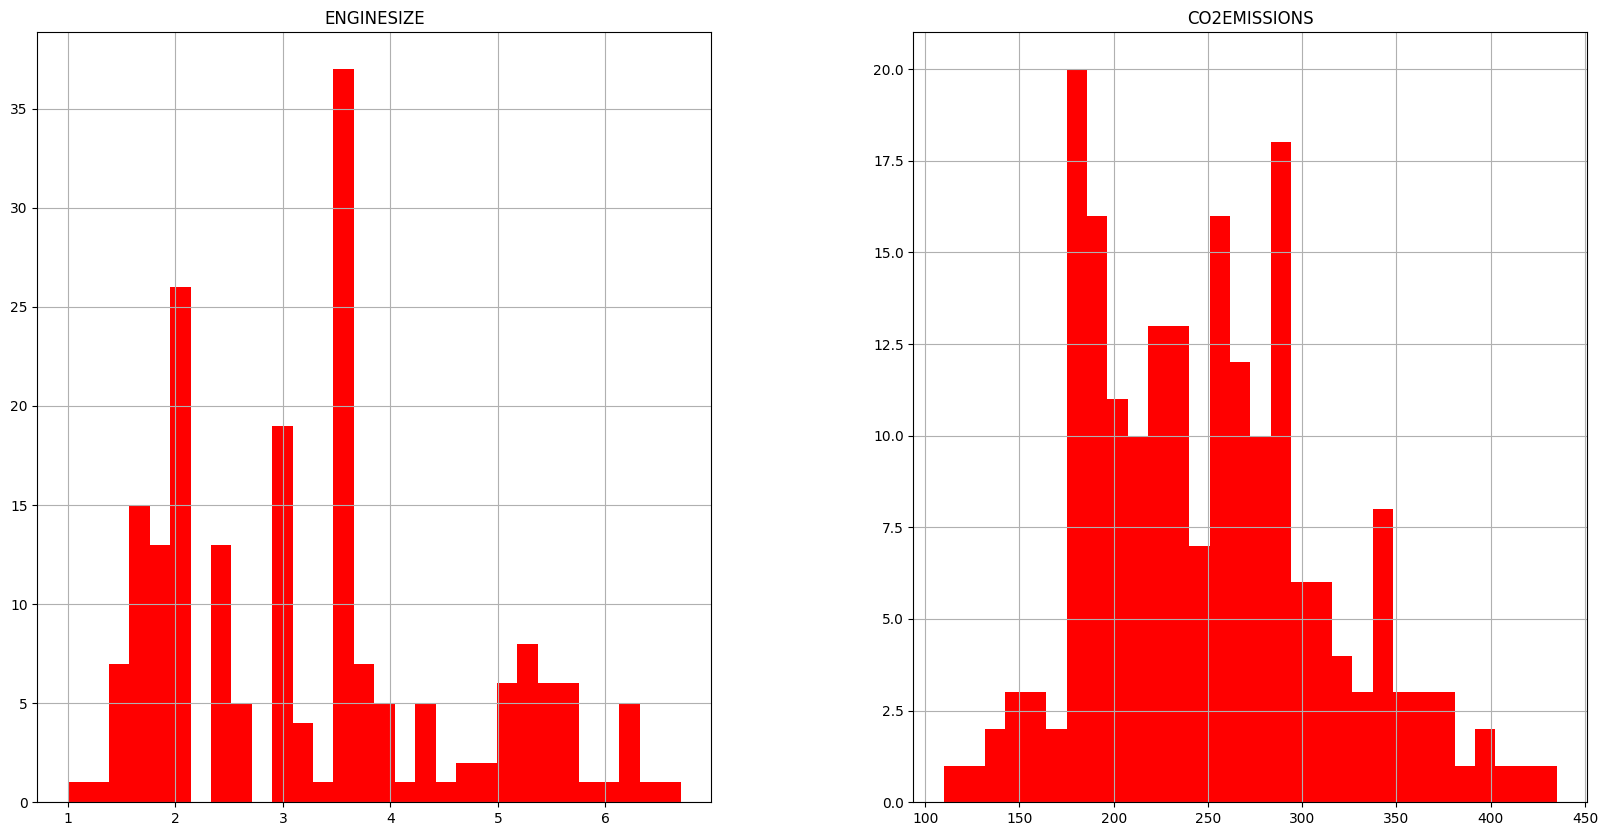

In [23]:
# Histogram Plotting (Data Distribution)
vehicle_df.hist(bins = 30, figsize = (20,10), color = 'r')

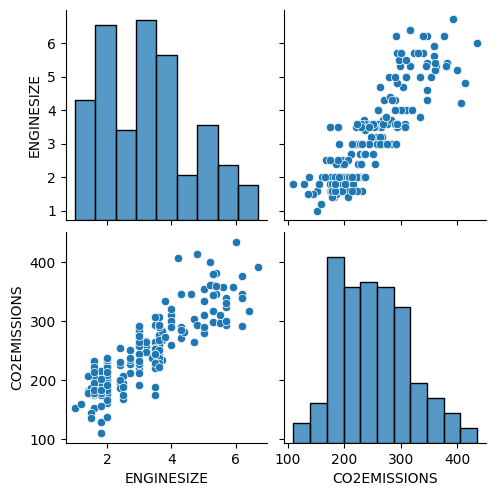

In [24]:
# Plot Pairplot (Variables Relationship)
sns.pairplot(vehicle_df)

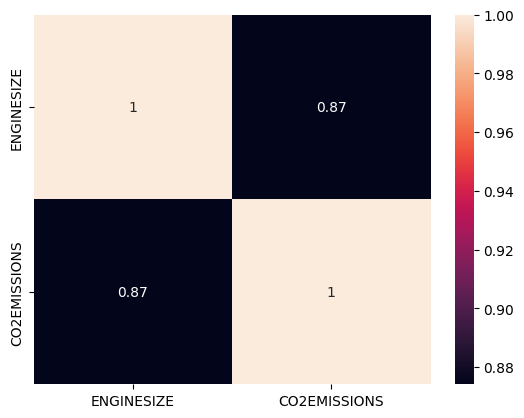

In [8]:
# Correlation Matrix
corr_matrix = vehicle_df.corr()
sns.heatmap(corr_matrix, annot = True)
plt.show()

<Axes: xlabel='ENGINESIZE', ylabel='CO2EMISSIONS'>

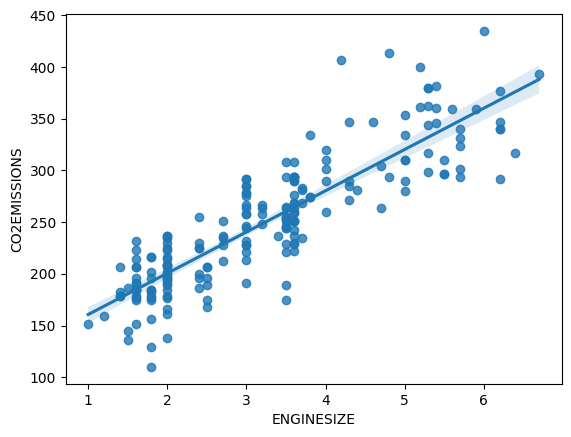

In [26]:
# Regression Plot with Seaborn (straight line fit between "CO2 emissions" and "Engine Size")
sns.regplot(x='ENGINESIZE', y='CO2EMISSIONS', data=df)

3) TRAINING AND TESTING DATA

In [27]:
X = df[['ENGINESIZE']]
y = df[['CO2EMISSIONS']]

In [28]:
X

,ENGINESIZE
732,4.7
657,3.5
168,3.6
86,3.0
411,2.0
...,...
936,1.8
541,3.5
817,2.0
884,3.8


In [29]:
y

,CO2EMISSIONS
732,304
657,221
168,294
86,221
411,207
...,...
936,184
541,244
817,191
884,274


In [30]:
X.shape

(200, 1)

In [31]:
y.shape

(200, 1)

In [32]:
X = np.array(X)
y = np.array(y)

In [33]:
X.shape

(200, 1)

In [34]:
# split the data into test and train sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=72)

In [35]:
X_train.shape

(150, 1)

In [36]:
X_test.shape

(50, 1)

In [37]:
print(X)

[[4.7]
 [3.5]
 [3.6]
 [3. ]
 [2. ]
 [3. ]
 [3.6]
 [4. ]
 [5. ]
 [3.6]
 [3.6]
 [6.7]
 [3.2]
 [3.5]
 [3.6]
 [3.5]
 [1.6]
 [3.6]
 [1.6]
 [5.3]
 [5. ]
 [1.8]
 [3.2]
 [3.7]
 [3. ]
 [1.8]
 [2. ]
 [1.6]
 [5.5]
 [3.2]
 [5.4]
 [2.4]
 [1.8]
 [5. ]
 [3. ]
 [4.7]
 [4. ]
 [5.3]
 [2. ]
 [2.5]
 [1.6]
 [1.6]
 [1.4]
 [2.5]
 [4. ]
 [1.6]
 [3. ]
 [3. ]
 [2. ]
 [5.2]
 [6.2]
 [3.6]
 [2. ]
 [3.7]
 [3. ]
 [5.3]
 [5.3]
 [5.7]
 [2. ]
 [4.3]
 [4. ]
 [4.3]
 [4.4]
 [3.6]
 [1.6]
 [3.4]
 [1.4]
 [4.8]
 [3. ]
 [3.7]
 [5. ]
 [2. ]
 [3.5]
 [2. ]
 [2. ]
 [3.6]
 [5.3]
 [6.2]
 [6.2]
 [3.5]
 [2.4]
 [1.8]
 [2.7]
 [3.5]
 [1.6]
 [3. ]
 [3. ]
 [2. ]
 [5.7]
 [2. ]
 [2.7]
 [4.2]
 [3.5]
 [1.8]
 [2. ]
 [2. ]
 [2.4]
 [3.5]
 [3.6]
 [5.6]
 [6.2]
 [2.5]
 [3.6]
 [2.4]
 [3.6]
 [1. ]
 [3. ]
 [2. ]
 [2.4]
 [2. ]
 [1.5]
 [3.5]
 [3.6]
 [2.7]
 [4.6]
 [3.6]
 [3.7]
 [4.8]
 [3.6]
 [1.6]
 [3.5]
 [1.5]
 [2.7]
 [1.8]
 [3. ]
 [2.4]
 [3.6]
 [2. ]
 [5.7]
 [2. ]
 [1.6]
 [1.6]
 [6. ]
 [1.8]
 [3.5]
 [3. ]
 [3. ]
 [5.5]
 [2. ]
 [4. ]
 [5.7]
 [3.5]
 [1.6]

In [38]:
# We can see that data have been shuffled by "train_test_split
X_train

array([[1.6],
       [5. ],
       [1.8],
       [3. ],
       [2.4],
       [1.8],
       [3. ],
       [2. ],
       [6.7],
       [1.8],
       [3. ],
       [1.6],
       [3. ],
       [2. ],
       [3.6],
       [3.5],
       [6.4],
       [5.6],
       [3.6],
       [1.8],
       [2.7],
       [3.6],
       [5.3],
       [2.7],
       [3.6],
       [4.7],
       [4.7],
       [1.6],
       [2. ],
       [3.7],
       [3.6],
       [3. ],
       [2. ],
       [1.6],
       [1.6],
       [1.8],
       [6.2],
       [4.8],
       [1.6],
       [5.3],
       [2. ],
       [2.5],
       [3.5],
       [3.6],
       [1.4],
       [2.7],
       [1.4],
       [3.6],
       [4.2],
       [2. ],
       [4.3],
       [1.6],
       [3.6],
       [2. ],
       [2.4],
       [2.4],
       [3. ],
       [3.6],
       [3.6],
       [3. ],
       [6.2],
       [2.5],
       [3.2],
       [6. ],
       [2. ],
       [3.4],
       [3.5],
       [3.6],
       [5.7],
       [3.5],
       [5.9],
      

4) TRAIN A LINEAR REGRESSION MODEL

In [39]:
# using linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression(fit_intercept = True) # Fit intercept is the "b" parameter (y = b + mx)
lr.fit(X_train, y_train)

LinearRegression()

In [40]:
# Checking the accuracy
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
mse

943.8801612424729

In [41]:
print('Linear Model Coefficient (m): ', lr.coef_)
print('Linear Model Coefficient (b): ', lr.intercept_)

Linear Model Coefficient (m):  [[38.93028095]]
Linear Model Coefficient (b):  [123.78371839]


5) EVALUATE TRAINED MODEL PERFORMANCE

In [42]:
y_pred

array([[201.64428028],
       [221.10942075],
       [240.57456122],
       [178.28611171],
       [260.0397017 ],
       [170.50005552],
       [260.0397017 ],
       [345.68631978],
       [326.2211793 ],
       [260.0397017 ],
       [291.18392645],
       [267.82575789],
       [279.50484217],
       [193.85822409],
       [193.85822409],
       [330.1142074 ],
       [193.85822409],
       [201.64428028],
       [240.57456122],
       [221.10942075],
       [248.36061741],
       [263.93272979],
       [260.0397017 ],
       [228.89547694],
       [334.00723549],
       [365.15146025],
       [217.21639266],
       [291.18392645],
       [279.50484217],
       [201.64428028],
       [240.57456122],
       [193.85822409],
       [201.64428028],
       [302.86301074],
       [240.57456122],
       [201.64428028],
       [334.00723549],
       [318.43512311],
       [201.64428028],
       [228.89547694],
       [186.0721679 ],
       [295.07695455],
       [201.64428028],
       [201

Text(0.5, 1.0, 'CO2 Emissions vs. Engine Size')

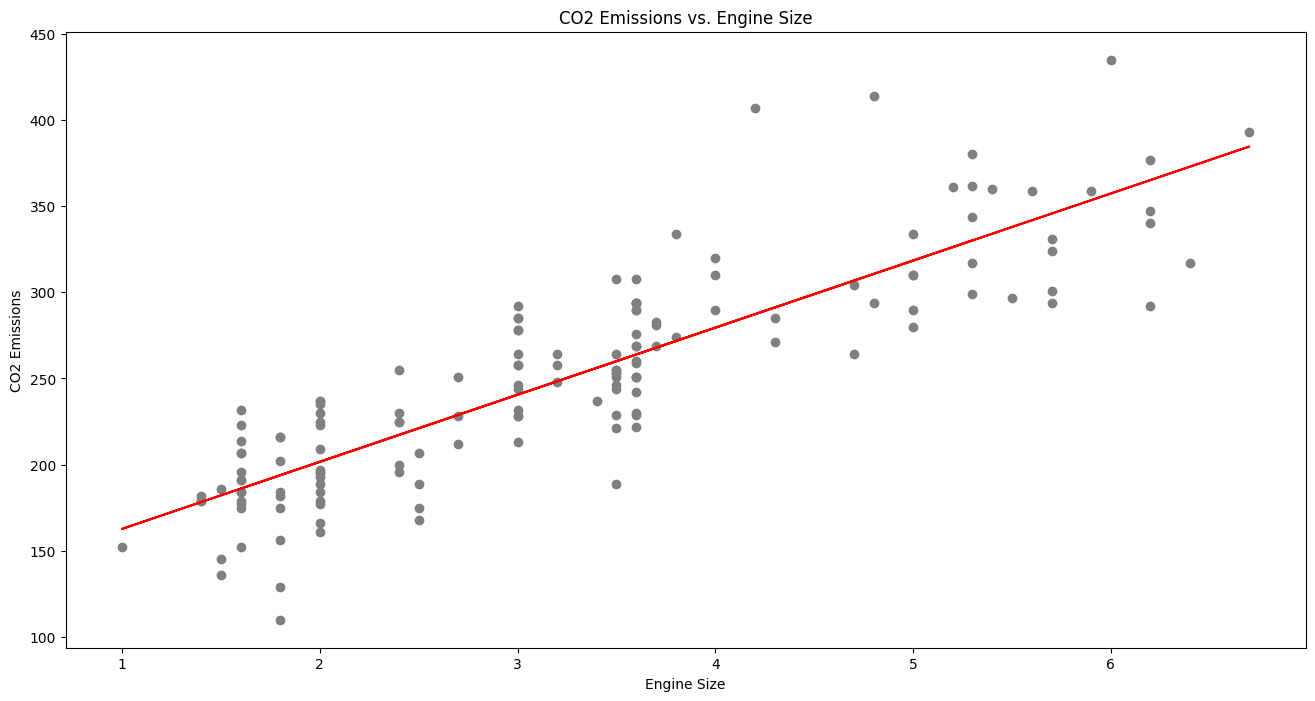

In [43]:
# Plotting the TRAIN DATA
plt.figure(figsize=(16,8))
plt.scatter(X_train, y_train, color='gray')
plt.plot(X_train, lr.predict(X_train), color='red')
plt.ylabel('CO2 Emissions')
plt.xlabel('Engine Size')
plt.title('CO2 Emissions vs. Engine Size')

6) MAKING PREDICTIONS

In [44]:
new_value = [[5.0]] # data untuk diprediksi
new_prediction = lr.predict(new_value)
new_prediction

array([[318.43512311]])

7) SAVE THE MODEL

In [45]:
import joblib

model_file = open("linear_regression_co2.pkl", "wb")
joblib.dump(lr, model_file)
model_file.close()

In [46]:
files.download('linear_regression_co2.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>